In [26]:
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from glob import glob
import time
import json
from tqdm import tqdm

import torch
from transformers import OwlViTProcessor, OwlViTForObjectDetection
from transformers import Owlv2Processor, Owlv2ForObjectDetection

device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

## 1. 工具函数

In [3]:
def xyxy_to_xywh(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]
    
    w = x2 - x1
    h = y2 - y1
    return [x1, y1, w, h]

def xyxy_get_area(coords):
    x1 = coords[0]
    y1 = coords[1]
    x2 = coords[2]
    y2 = coords[3]

    w = x2 - x1
    h = y2 - y1
    return w*h

def show_img(img, bboxes = None, tag = None, captions = None):
    '''
        Function: used to show image and corresponding bounding boxes.
    '''
    fig, ax = plt.subplots()
    
    ax.imshow(img)
    
    if bboxes is not None:
        for i, bbox in enumerate(bboxes):
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            if tag is not None:
                ax.text(x, y-8, str(i+1), color='r', fontsize=11, weight='bold')
            if captions is not None:
                ax.text(x+20, y-8, captions[i], color='r', fontsize=11, weight='bold')
    plt.axis("off")
    plt.show()

In [4]:
def load_owlv2(model_id = "google/owlv2-large-patch14-ensemble"):
    model = Owlv2ForObjectDetection.from_pretrained(model_id).eval().to(device)
    processor = Owlv2Processor.from_pretrained(model_id)
    return model, processor

In [82]:
def owlv2_processor(model, processor, img, caption):
    with torch.no_grad():
        inputs = processor(text = caption, images = img, return_tensors = "pt").to(device)
        start_time = time.time()
        outputs = model(**inputs)
        inference_time = time.time() - start_time

    del model

    results = processor.post_process_grounded_object_detection(
        outputs=outputs, 
        target_sizes=torch.tensor([(img.height, img.width)]), 
        threshold=0.30, 
        text_labels=caption
    )
    # print(results)
    del processor
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    bboxes = results[0]["boxes"].cpu().tolist()
    scores = results[0]["scores"].cpu().tolist()
    labels = results[0]["text_labels"]
    areas = [xyxy_get_area(bbox) for bbox in bboxes]

    result = []
    for bbox, area, label, score in zip(bboxes, areas, labels, scores):
        result.append({
            "bbox":xyxy_to_xywh(np.array(bbox).astype(np.int64).tolist()),
            "area":xyxy_get_area(bbox),
            "label":label,
            "score":score
        })

    return result, img.size, inference_time

## 2. owlv2模型推断

In [86]:
model_id = "google/owlv2-large-patch14-ensemble"#"google/owlv2-base-patch16-ensemble" # google/owlv2-large-patch14-ensemble
model, processor = load_owlv2(model_id = model_id)

# florence是对单复数敏感的。cylinder 只会获取一个bbox；cylinders 会获取所有的bbox.
# caption = [["cylinders",]]

# img_path_list = glob("./imgs/dataset/1. gas cylinder/*.jpg")
# print(f"The quantity of images: {len(img_path_list)}")

[{'bbox': [813, 80, 490, 282], 'area': 138248.1846425403, 'label': 'excavators', 'score': 0.5116066932678223}, {'bbox': [466, 158, 452, 717], 'area': 323796.54485582514, 'label': 'excavators', 'score': 0.5693666338920593}, {'bbox': [487, 114, 869, 760], 'area': 660221.4771533618, 'label': 'excavators', 'score': 0.44157010316848755}]


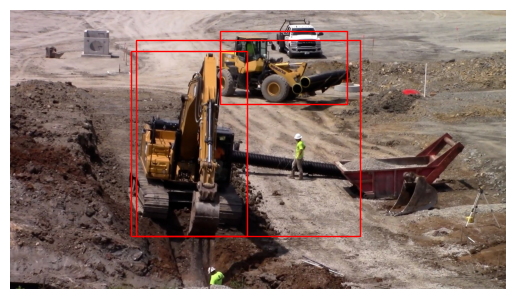

In [85]:
# 测试代码

# img_path = "./imgs/dataset/5. vehicle/5_2_3.jpg"
# img = Image.open(img_path).convert("RGB")
# caption = [["excavators"]]

# outcome, image_size, inference_time = owlv2_processor(
#     model=model, 
#     processor=processor, 
#     img = img, 
#     caption=caption
# )

# print(outcome)
# bboxes = [item["bbox"] for item in outcome ]
# show_img(img, bboxes)

In [87]:
path_list = [
    "./imgs/dataset/1. gas cylinder/*.jpg",
    "./imgs/dataset/2. working at height/*.jpg",
    "./imgs/dataset/3. worker with hardhat & vest/*.jpg",
    "./imgs/dataset/4. working with eye protection/*.jpg",
    "./imgs/dataset/5. vehicle/*.jpg",
]
caption_list = [
    [["cylinders", "gas cylinders"]],
    [["workers",]],
    [["workers",]],
    [["workers",]],
    [["excavators"]],
]

In [88]:
for j in range(len(path_list)):
    img_path_list = glob(path_list[j])
    print(f"The quantity of images: {len(img_path_list)}")
    caption = caption_list[j]

    img_outcome = {}
    for i, img_path in tqdm(enumerate(img_path_list), total = len(img_path_list)):
        img = Image.open(img_path).convert("RGB")
    
        outcome, image_size, inference_time = owlv2_processor(
            model=model, 
            processor=processor, 
            img = img, 
            caption=caption
        )
    
        img_outcome[i] = {
            "img_path":img_path,
            "img_size":image_size, #[width, height]
            "inference_time":inference_time,
            "result":outcome
        }
        
    with open(f"./results/owlv2_{j+1}_2.json", "w") as fp:
        fp.write(json.dumps(img_outcome))

The quantity of images: 305


100%|████████████████████████████████████████████████████████████████████████████████| 305/305 [27:04<00:00,  5.33s/it]


The quantity of images: 570


100%|████████████████████████████████████████████████████████████████████████████████| 570/570 [52:45<00:00,  5.55s/it]


The quantity of images: 439


100%|████████████████████████████████████████████████████████████████████████████████| 439/439 [41:08<00:00,  5.62s/it]


The quantity of images: 409


100%|████████████████████████████████████████████████████████████████████████████████| 409/409 [38:15<00:00,  5.61s/it]


The quantity of images: 837


100%|██████████████████████████████████████████████████████████████████████████████| 837/837 [1:23:07<00:00,  5.96s/it]


In [ ]:
img_outcome = {}
for i, img_path in tqdm(enumerate(img_path_list), total = len(img_path_list)):
    img = Image.open(img_path).convert("RGB")

    outcome, image_size, inference_time = owlv2_processor(
        model=model, 
        processor=processor, 
        img = img, 
        caption=caption
    )

    img_outcome[i] = {
        "img_path":img_path,
        "img_size":image_size, #[width, height]
        "inference_time":inference_time,
        "result":outcome
    }

In [59]:
with open(f"./results/owlv2_{1}.json", "w") as fp:
    fp.write(json.dumps(img_outcome))

## 3. 测试代码

In [42]:
# img = Image.open("./imgs/testing.jpg")
# text_labels = [["cylinders",]]

# # google/owlvit-base-patch32
# # google/owlvit-large-patch14
# # google/owlv2-base-patch16-ensemble

# # model = OwlViTForObjectDetection.from_pretrained("google/owlvit-base-patch32").eval().to(device)
# # processor = OwlViTProcessor.from_pretrained("google/owlvit-base-patch32")

# processor = Owlv2Processor.from_pretrained("google/owlv2-base-patch16-ensemble")
# model = Owlv2ForObjectDetection.from_pretrained("google/owlv2-base-patch16-ensemble").eval().to(device)

# with torch.no_grad():
#     inputs = processor(text = text_labels, images = img, return_tensors = "pt").to(device)
#     outputs = model(**inputs)

# del model

In [43]:
# results = processor.post_process_grounded_object_detection(
#     outputs=outputs, 
#     target_sizes=torch.tensor([(img.height, img.width)]), 
#     threshold=0.2, 
#     text_labels=text_labels
# )

# del processor

# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

# print(results)